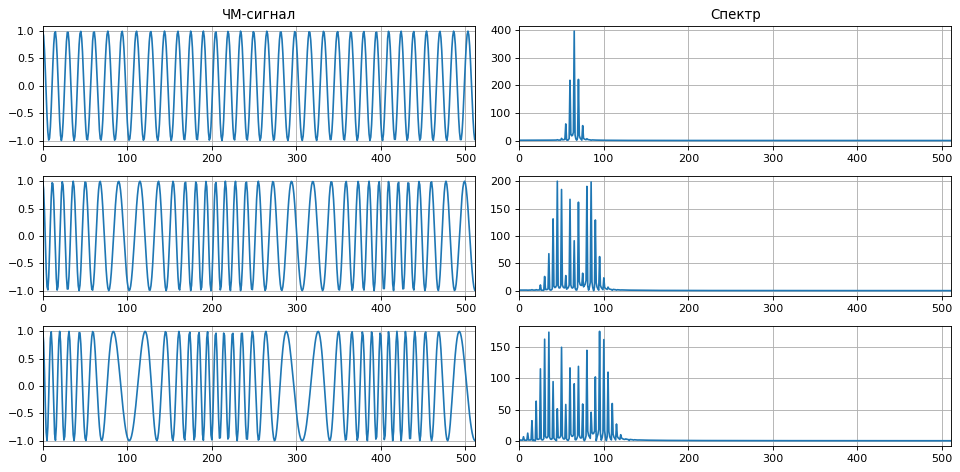

In [5]:
# построение графиков ЧМ-сигналов

import numpy as np
import matplotlib.pyplot as plt

# команда для отображения графиков прямо внутри ноутбука
%matplotlib inline

# функция для генерации частотно-модулированного (ЧМ) сигнала
def signal_fm(amp=1.0, kd=0.25, fc=10.0, fs=2.0, period=100):
    # создаем массив времени t, равномерно распределенный от 0 до 2π
    t = 2.0 * np.pi * np.linspace(0, 1, period)
    # возвращаем значение ЧМ сигнала:
    # - амплитуда: 'amp'
    # - аргумент косинуса включает базовую частоту 'fc' и модуляцию через функцию синуса
    return amp * np.cos(fc * t + (kd / fs) * np.sin(fs * t))

N = 1024  # длина сигнала (количество выборок)
fs = 5    # частота дискретизации (частота выборки)
fc = 65   # частота несущего сигнала
kd = [5, 25, 40]  # коэффициенты модуляции для разных сигналов

# создаем список сигналов с разными коэффициентами модуляции
sig = [signal_fm(amp=1.0, kd=i, fc=fc, fs=fs, period=N) for i in kd]

# вычисляем спектры сигналов с помощью быстрого преобразования Фурье (FFT)
sft = np.abs(np.fft.fft(sig, axis=1))

# создаем фигуру для отображения результатов
plt.figure(figsize=(12, 6), dpi=80)

# цикл по каждому сигналу и его спектру
for i, freq in enumerate(kd):
    # первый столбец - сам сигнал
    plt.subplot(len(kd), 2, 2*i+1)  # позиция подграфика
    if i == 0:
        plt.title('ЧМ-сигнал')  # заголовок для первого сигнала
    plt.plot(sig[i])  # построение сигнала
    plt.xlim([0, N//2 - 1])  # ограничение по оси X до половины длины сигнала
    plt.grid(True)  # включение сетки

    # второй столбец - спектр сигнала
    plt.subplot(len(kd), 2, 2*i+2)  # позиция для спектра
    if i == 0:
        plt.title('Спектр')  # заголовок для спектра
    plt.plot(sft[i])  # построение спектра
    plt.xlim([0, N//2 - 1])  # ограничение по оси X
    plt.grid(True)  # включение сетки

plt.tight_layout()  # автоматическая настройка расположения графиков